# 01: Preprocessing the PBMC 3k dataset with Python
1. Data Download
2. QC
3. Normalization
4. Dimensionality Reduction and Manifold Embedding
5. Clustering
6. DEA and Annotation

## Reference
- [Scanpy's tutorial](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html)

---
## 1. Data Download
- Downloading the PBMC3k dataset from [10x Genomics](https://www.10xgenomics.com/datasets/3-k-pbm-cs-from-a-healthy-donor-1-standard-1-1-0)'s source

In [1]:
%%bash

DATA_DIR="./data"
FILE_NAME="pbmc3k"
SRC="http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz"

mkdir -p "$DATA=DIR"

if [ -f "$DATA_DIR/$FILE_NAME/matrix.mtx" ]; then
    echo "$FILE_NAME data already exists. Skipping download"
else
    wget -q $SRC -O "$DATA_DIR/$FILE_NAME.tar.gz"
    tar -xzf "$DATA_DIR/$FILE_NAME.tar.gz" -C "$DATA_DIR"
    mkdir -p "$DATA_DIR/$FILE_NAME"
    mv "$DATA_DIR/filtered_gene_bc_matrices/hg19/"* "$DATA_DIR/$FILE_NAME"
    rm -rf "$DATA_DIR/filtered_gene_bc_matrices" "$DATA_DIR/$FILE_NAME.tar.gz"
    echo "Download and extraction completed!"
fi

pbmc3k data already exists. Skipping download


---
## 2. QC
### 2-1. Thresholding QC metrics

In [2]:
import glob
import logging
import os
import subprocess
from typing import NamedTuple
import warnings

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
logging.getLogger("fontTools.subset").setLevel(logging.WARNING)
warnings.filterwarnings("ignore")

import celltypist
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import polars as pl
import scanpy as sc
import seaborn as sns

from basalcelldemo_tools.anndata import transfer_embedding_info
from basalcelldemo_tools.preferences import kwarg_savefig, OUTPUT_DIR, DATA_DIR, CellTypist_Models

In [3]:
adata = sc.read_10x_mtx("./data/pbmc3k")

In [4]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [5]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


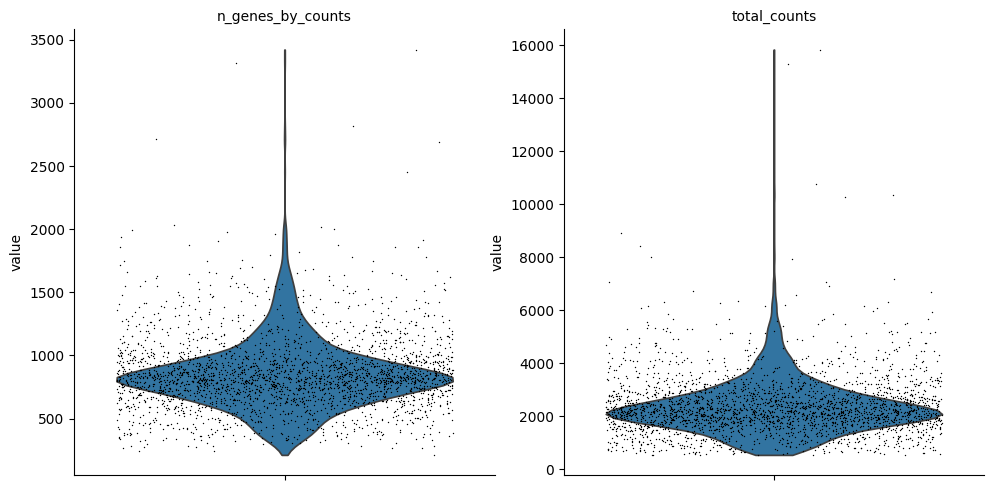

In [6]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)

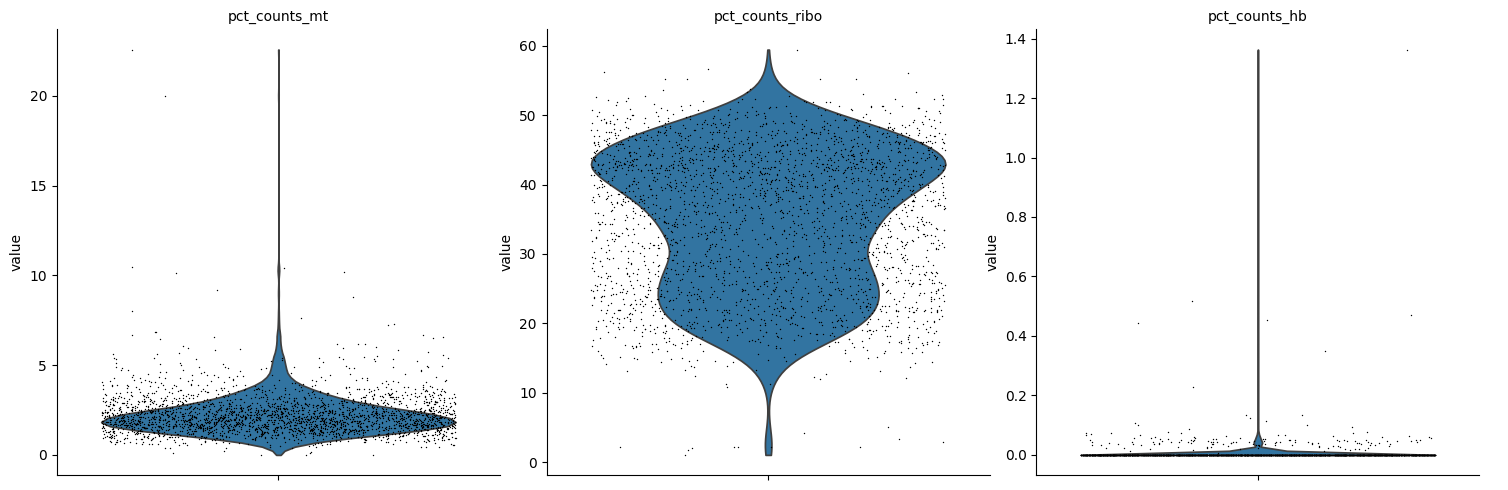

In [7]:
sc.pl.violin(
    adata,
    ["pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True,
)

In [8]:
filtered_cells = pl.from_pandas(adata.obs.reset_index()).filter(
    (500 <= pl.col("n_genes_by_counts")) & \
    (pl.col("n_genes_by_counts") <= 1500) & \
    (pl.col("total_counts") < 6000) & \
    (pl.col("pct_counts_mt") < 5) & \
    (20 < pl.col("pct_counts_ribo")) & \
    (pl.col("pct_counts_ribo") < 50) & \
    (pl.col("pct_counts_hb") < 0.1)
).select("index").to_pandas().set_index("index").index

adata = adata[filtered_cells, :].copy()

In [9]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

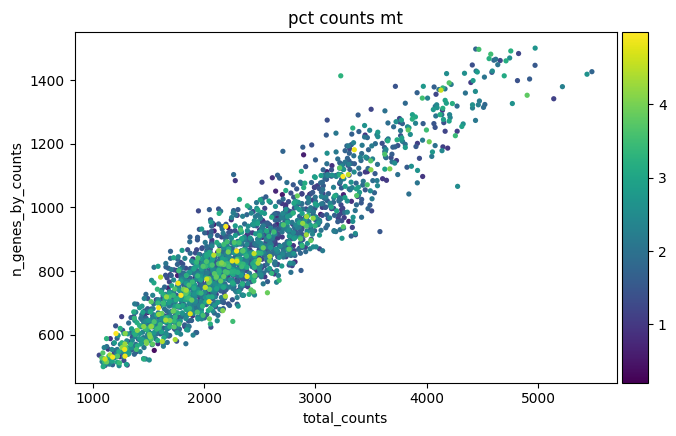

In [10]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

### 2-2. Doublet Detection

In [11]:
sc.pp.scrublet(adata)

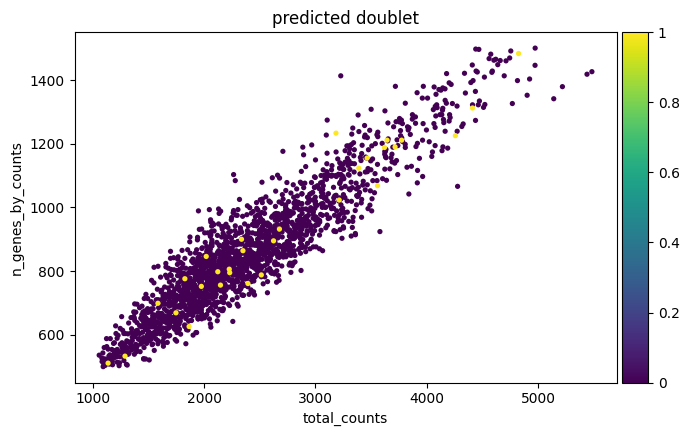

In [12]:
sc.pl.scatter(
    adata, 
    x="total_counts", 
    y="n_genes_by_counts", 
    color="predicted_doublet"
)

In [13]:
adata = adata[~adata.obs["predicted_doublet"], :].copy()

---
## 3. Normalization

In [14]:
adata.layers["counts"] = adata.X.copy()

In [15]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

---
## 4. Dimensionality Reduction and Manifold Embedding
### 4-1. Feature Selection

In [16]:
ad_manifold = adata.copy()

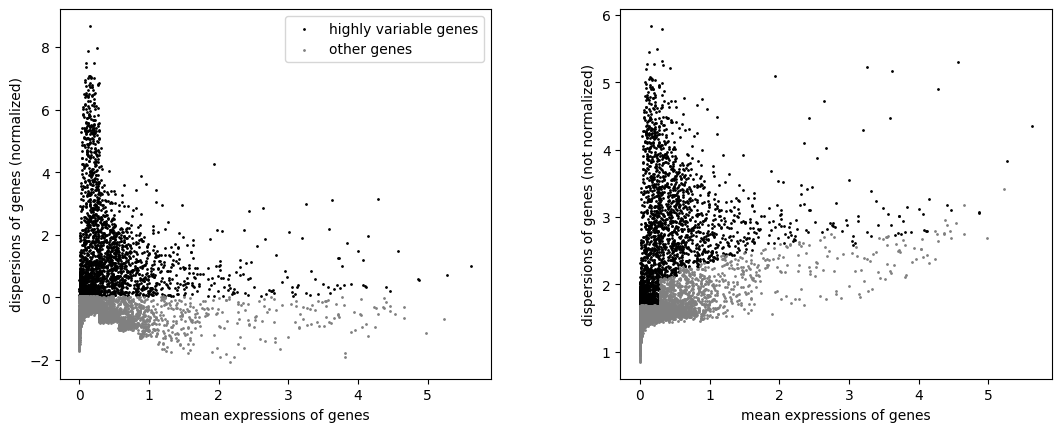

In [17]:
sc.pp.highly_variable_genes(ad_manifold, n_top_genes=3000)
sc.pl.highly_variable_genes(ad_manifold)

In [18]:
ad_manifold = ad_manifold[:, ad_manifold.var.highly_variable]

### 4-2. Dimensionality Reduction

In [19]:
sc.tl.pca(ad_manifold, svd_solver="arpack")

### 4-3. Manifold Embedding

In [20]:
sc.pp.neighbors(ad_manifold, n_pcs=50)

In [21]:
sc.tl.umap(ad_manifold)

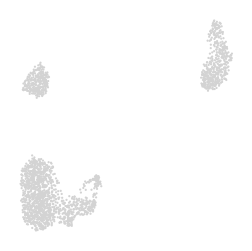

In [22]:
fig, ax = plt.subplots(figsize=(3, 3))

sc.pl.umap(ad_manifold, ax=ax, size=10, show=False)
ax.axis("off");

In [23]:
transfer_embedding_info(
    adata_source=ad_manifold,
    adata_target=adata,
    overwrite=True
)
del ad_manifold

---
## 5. Clustering

In [24]:
sc.tl.leiden(adata, resolution=1)

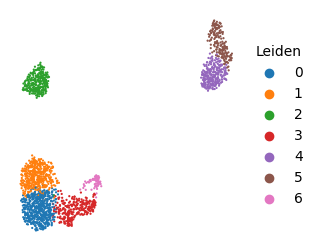

In [25]:
fig, ax = plt.subplots(figsize=(3, 3))

sc.pl.umap(adata, ax=ax, size=10, show=False, color="leiden")
ax.axis("off");
ax.set(title="")
ax.legend(
    loc="center left", bbox_to_anchor=(1, .5),
    title="Leiden", frameon=False
);

fig.savefig(OUTPUT_DIR / "umap.pdf", **kwarg_savefig)

---
## 6. DEA and Annotation
### 6-1. DEA

In [26]:
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")

In [27]:
degs = pl.from_pandas(
    sc.get.rank_genes_groups_df(adata, group=None)
).filter(
    (pl.col("pvals_adj") < 0.05) &\
    (pl.col("logfoldchanges") > 1)
).select(pl.col("group").cast(str), "names", "logfoldchanges", "pvals_adj")
degs.write_parquet(DATA_DIR / "degs.pq")
degs

group,names,logfoldchanges,pvals_adj
str,str,f32,f64
"""0""","""LTB""",2.279514,2.0982e-85
"""0""","""IL32""",2.386184,3.6982e-74
"""0""","""LDHB""",1.743769,3.9248e-66
"""0""","""IL7R""",2.312467,1.8114e-63
"""0""","""CD3D""",1.951366,2.8265e-49
…,…,…,…
"""6""","""PTGDR""",3.548436,0.041779
"""6""","""PLEKHF1""",3.495875,0.04282
"""6""","""MSN""",1.374327,0.045105


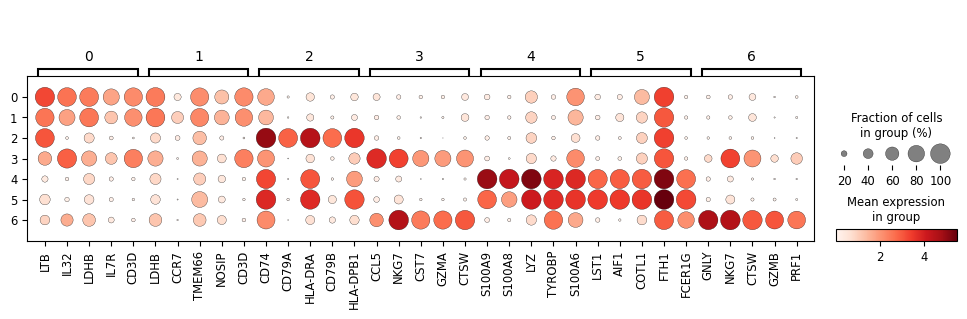

In [28]:
fig, ax = plt.subplots(figsize=(12, 3))

n_degs = 5

sc.pl.dotplot(
    adata, 
    dict(
        degs.group_by(
            "group", maintain_order=True
        ).agg(
            pl.col("names").head(n_degs)
        ).iter_rows()
    ),
    "leiden", ax=ax
)

ax.set(title=f"Top {n_degs} DEGs")

fig.savefig(OUTPUT_DIR / f"top{n_degs}degs.pdf", **kwarg_savefig)

In [29]:
sc.get.obs_df(
    adata, 
    keys=degs["names"].unique(maintain_order=True).to_numpy().tolist() + ["leiden"]
).reset_index().to_parquet(DATA_DIR / "expressions.pq")

In [30]:
n_degs = 10

degs.group_by(
    "group", maintain_order=True
).agg(
    pl.col("names").head(n_degs)
).explode("names").unique(
    "names", maintain_order=True
).with_columns(
     leiden_colors=pl.col("group").replace(
        {str(i): v for i, v in enumerate(adata.uns["leiden_colors"])}
    )
).write_parquet(DATA_DIR / "top_degs.pq")

### 6-2. Automated Annotation with CellTypist

In [31]:
celltypist.models.models_path = str(CellTypist_Models)

if not glob.glob(str(CellTypist_Models / ".pkl")):
    celltypist.models.download_models()

📂 Storing models in /Users/yujiokano/Develop/BasalCellDemo/basalcelldemo_tools/celltypist_models
⏩ Skipping [1/61]: Immune_All_Low.pkl (file exists)
⏩ Skipping [2/61]: Immune_All_High.pkl (file exists)
⏩ Skipping [3/61]: Adult_COVID19_PBMC.pkl (file exists)
⏩ Skipping [4/61]: Adult_CynomolgusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [5/61]: Adult_Human_MTG.pkl (file exists)
⏩ Skipping [6/61]: Adult_Human_PancreaticIslet.pkl (file exists)
⏩ Skipping [7/61]: Adult_Human_PrefrontalCortex.pkl (file exists)
⏩ Skipping [8/61]: Adult_Human_Skin.pkl (file exists)
⏩ Skipping [9/61]: Adult_Human_Vascular.pkl (file exists)
⏩ Skipping [10/61]: Adult_Mouse_Gut.pkl (file exists)
⏩ Skipping [11/61]: Adult_Mouse_OlfactoryBulb.pkl (file exists)
⏩ Skipping [12/61]: Adult_Pig_Hippocampus.pkl (file exists)
⏩ Skipping [13/61]: Adult_RhesusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [14/61]: Adult_cHSPCs_Illumina.pkl (file exists)
⏩ Skipping [15/61]: Adult_cHSPCs_Ultima.pkl (file exists)
⏩ Skipp

In [32]:
model_ct = celltypist.models.Model.load(model="Immune_All_Low.pkl")

In [33]:
annotated = celltypist.annotate(
    adata, model=model_ct, 
    majority_voting=True
).to_adata(adata, prefix="celltypist_")

🔬 Input data has 2070 cells and 13123 genes
🔗 Matching reference genes in the model
🧬 4007 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


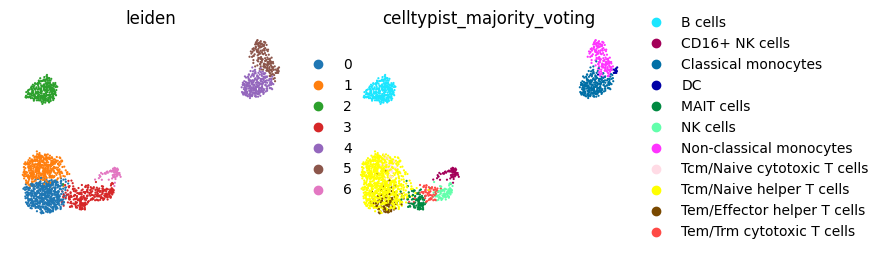

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

candidate_size = adata.obs["celltypist_majority_voting"].unique().size
candidate_colors = {
    v: mcolors.to_hex(
        sc.plotting.palettes.godsnot_102[i]
    ) for i, v in enumerate(adata.obs["celltypist_majority_voting"].unique())
}

for a, hue in zip(ax.ravel(), ["leiden", "celltypist_majority_voting"]):
    sc.pl.umap(
        annotated, ax=a, size=10, show=False, color=hue,
        palette=adata.uns["leiden_colors"] if hue == "leiden" else candidate_colors
    )
    a.axis("off");

    a.set_aspect('equal')
    a.set(title=hue)
    a.legend(
        loc="center left", bbox_to_anchor=(1, .5),  
        frameon=False
    )

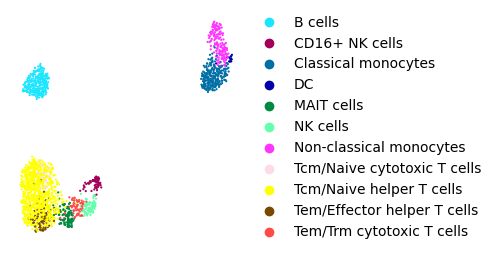

In [35]:
fig, ax = plt.subplots(figsize=(3, 3))

sc.pl.umap(
    adata, color="celltypist_majority_voting", ax=ax, 
    size=10, show=False, palette=candidate_colors
)

ax.axis("off");

ax.set(title="")
a.legend(
    loc="center left", bbox_to_anchor=(1, .5),  
    frameon=False, title="CellTypist"
)

fig.savefig(OUTPUT_DIR / "umap_celltypist.pdf", **kwarg_savefig)

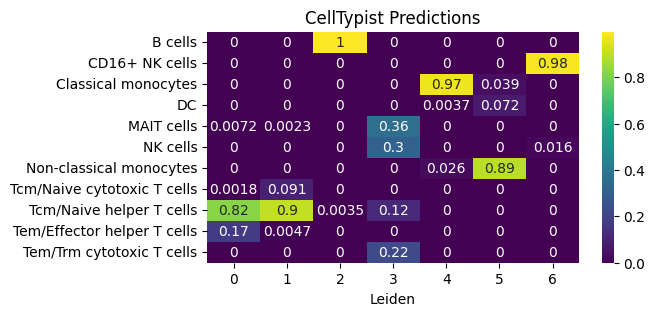

In [36]:
fig, ax = plt.subplots(figsize=(6, 3))

df_ct = pd.crosstab(
    annotated.obs["leiden"], 
    annotated.obs["celltypist_majority_voting"]
)

sns.heatmap(
    data=(df_ct.T / df_ct.sum(axis=1)), cmap="viridis", ax=ax, 
    annot=True
)

ax.set(title="CellTypist Predictions", xlabel="Leiden", ylabel="")

fig.savefig(OUTPUT_DIR / "celltypist.pdf", **kwarg_savefig)

In [37]:
df_obs = pl.DataFrame(
    annotated.obs[["leiden", "celltypist_majority_voting"]]
)

mapping_df = (
    df_obs.group_by("leiden", maintain_order=True)
    .agg(pl.col("celltypist_majority_voting").mode().first().alias("ct"))
    .cast(pl.String)
    .sort("leiden")
    .with_columns(
        annotation=pl.when(pl.len().over("ct") > 1)
        .then(
            pl.col("ct") + " #" + pl.int_range(1, pl.len() + 1).over("ct").cast(pl.String)
        )
        .otherwise(pl.col("ct"))
    )
    .select("leiden", "annotation")
)

mapping_df

leiden,annotation
str,str
"""0""","""Tcm/Naive helper T cells #1"""
"""1""","""Tcm/Naive helper T cells #2"""
"""2""","""B cells"""
"""3""","""MAIT cells"""
"""4""","""Classical monocytes"""
"""5""","""Non-classical monocytes"""
"""6""","""CD16+ NK cells"""


In [38]:
adata.obs["annotation"] = adata.obs["leiden"].map(
    dict(zip(mapping_df["leiden"], mapping_df["annotation"]))
)

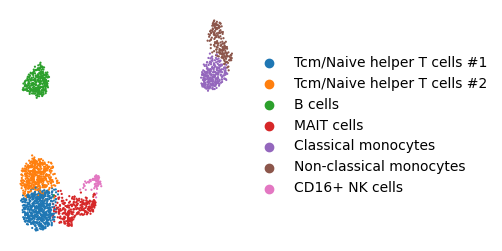

In [39]:
fig, ax = plt.subplots(figsize=(3, 3))

sc.pl.umap(
    adata, color="annotation", ax=ax, 
    size=10, show=False, palette=adata.uns["leiden_colors"]
)

ax.axis("off");

ax.set(title="")
a.legend(
    loc="center left", bbox_to_anchor=(1, .5),  
    frameon=False, title="Annotation"
)

fig.savefig(OUTPUT_DIR / "umap_with_annotation.pdf", **kwarg_savefig)

In [40]:
pl.from_pandas(
    adata.obs[
        ["leiden", "celltypist_majority_voting", "annotation"]
    ].astype(str).reset_index()
).with_columns(
    leiden_colors=pl.col("leiden").replace(
        {str(i): v for i, v in enumerate(adata.uns["leiden_colors"])}
    )
).with_columns(
    celltypist_colors=pl.col("celltypist_majority_voting").replace(
        candidate_colors
    )
).write_parquet(DATA_DIR / "annotations.pq")